In [1]:
# Cell 1: Imports and Setup
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Cell 2: Define Helper Functions and Classes
def calculate_class_weights(y_train):
    """Calculate weights inversely proportional to class frequencies"""
    class_counts = np.bincount(y_train.astype(int))
    class_weights = len(y_train) / (len(class_counts) * class_counts)
    return torch.FloatTensor([class_weights[0], class_weights[1]])

class ImprovedBiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=2, dropout=0.2):
        super(ImprovedBiLSTM, self).__init__()
        
        # Multi-layer LSTM with smaller hidden size
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0,
                            bidirectional=True)
        
        self.dropout = nn.Dropout(dropout)
        
        # Feature extraction layers
        self.fc1 = nn.Linear(hidden_size * 2, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 1)
        
        # Initialize final layer with negative bias to counter positive predictions
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.constant_(self.fc2.bias, -1.0)  # Start with negative bias
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        # Use last timestep from both directions
        out = lstm_out[:, -1, :]
        out = self.dropout(out)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out

class StockDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return (torch.FloatTensor(self.sequences[idx]),
                torch.FloatTensor([self.targets[idx]]))

def prepare_stock_data(df, feature_cols, seq_len=20, train_split=0.7, val_split=0.15):
    stock_data = df.sort_values('Date').reset_index(drop=True)
    
    all_sequences = []
    all_targets = []
    
    if len(stock_data) < seq_len + 1:
        raise ValueError("Not enough data to create sequences.")
        
    X_vals = stock_data[feature_cols].values
    y_vals = stock_data['Target'].values

    for i in range(seq_len, len(X_vals)):
        all_sequences.append(X_vals[i-seq_len:i])
        all_targets.append(y_vals[i])
    
    X_seq = np.array(all_sequences)
    y_seq = np.array(all_targets)
    
    # Split data
    train_idx = int(len(X_seq) * train_split)
    val_idx = int(len(X_seq) * (train_split + val_split))
    
    X_train, y_train = X_seq[:train_idx], y_seq[:train_idx]
    X_val, y_val = X_seq[train_idx:val_idx], y_seq[train_idx:val_idx]
    X_test, y_test = X_seq[val_idx:], y_seq[val_idx:]
    
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

In [3]:
# Cell 3: Load and Prepare Data
print("Loading and filtering data...")
df_full = pd.read_csv("../data/processed/stock_data_optimized.csv")

# Define the stock and features
STOCK_TO_USE = "AAPL"
FEATURES_TO_USE = [col for col in df_full.columns if col not in ['Date', 'Ticker', 'Target']]

# Filter data
df_filtered = df_full[df_full['Ticker'] == STOCK_TO_USE].copy()
essential_cols = FEATURES_TO_USE + ['Date', 'Ticker', 'Target']
df_final = df_filtered[essential_cols]

print(f"Data filtered for Ticker: {STOCK_TO_USE}")
print(f"Using Features: {FEATURES_TO_USE}")
print(f"Total samples: {len(df_final)}")

Loading and filtering data...
Data filtered for Ticker: AAPL
Using Features: ['Open', 'High', 'Low', 'Close', 'Volume', 'Log_Return', 'High_Low_Ratio', 'Close_Open_Ratio', 'Gap', 'RSI_14', 'MACD', 'BB_Position', 'ATR_14', 'ADX', 'Volume_Ratio_20', 'Volume_Price_Correlation', 'Close_vs_SMA20', 'Close_vs_SMA50', 'Close_vs_High20d', 'Volatility_20d', 'Return_3d', 'Return_5d', 'ROC_10', 'Momentum_10d', 'Volatility_5d', 'Volatility_Z20', 'High_PrevClose', 'Up_5d', 'OBV', 'Volume_Change_1d', 'Close_Z20', 'Drawdown_10d', 'RSI_14_Lag1', 'MACD_Lag1']
Total samples: 2844


In [4]:
# Cell 4: Create Sequences and Scale Data
print("\nCreating sequences...")
(X_train_unscaled, y_train), (X_val_unscaled, y_val), (X_test_unscaled, y_test) = prepare_stock_data(
    df_final,
    feature_cols=FEATURES_TO_USE,
    seq_len=30
)

print(f"Data: {len(X_train_unscaled)} train, {len(X_val_unscaled)} val, {len(X_test_unscaled)} test")
print(f"Features: {X_train_unscaled.shape[2]}")
print(f"Train class distribution: {np.bincount(y_train.astype(int))}")
print(f"Train class ratio: {np.bincount(y_train.astype(int))[1] / len(y_train):.3f}")

# Scale the data
scaler = StandardScaler()  # Try StandardScaler instead of MinMaxScaler
num_samples, seq_len, num_features = X_train_unscaled.shape
X_train_reshaped = X_train_unscaled.reshape(-1, num_features)
scaler.fit(X_train_reshaped)

X_train = scaler.transform(X_train_unscaled.reshape(-1, num_features)).reshape(X_train_unscaled.shape)
X_val = scaler.transform(X_val_unscaled.reshape(-1, num_features)).reshape(X_val_unscaled.shape)
X_test = scaler.transform(X_test_unscaled.reshape(-1, num_features)).reshape(X_test_unscaled.shape)

print(f"\nX_train stats after scaling - min: {X_train.min():.3f}, max: {X_train.max():.3f}")



Creating sequences...
Data: 1969 train, 422 val, 423 test
Features: 34
Train class distribution: [ 810 1159]
Train class ratio: 0.589

X_train stats after scaling - min: -36.044, max: 16.020


In [5]:
# Cell 5: Setup Model with Class Weights
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Calculate class weights
class_weights = calculate_class_weights(y_train)
print(f"Class weights: {class_weights}")

# Create datasets
train_dataset = StockDataset(X_train, y_train)
val_dataset = StockDataset(X_val, y_val)
test_dataset = StockDataset(X_test, y_test)

# Initialize model
model = ImprovedBiLSTM(
    input_size=X_train.shape[2],
    hidden_size=32,
    num_layers=2,
    dropout=0.2
).to(device)

# Setup loss with class weights
pos_weight = class_weights[1] / class_weights[0]
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

# Optimizer with lower learning rate
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
)

print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")


Device: cpu
Class weights: tensor([1.2154, 0.8494])

Model parameters: 44,609


In [6]:
# Cell 6: Training Loop with Debugging
train_losses, val_losses, train_accs, val_accs, learning_rates = [], [], [], [], []

num_epochs = 100
best_val_loss = float('inf')
patience_counter = 0
patience = 20

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("\nStarting training...")
for epoch in range(num_epochs):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    all_train_preds = []
    
    for batch_idx, (batch_X, batch_y) in enumerate(train_loader):
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        
        outputs = model(batch_X).squeeze()
        loss = criterion(outputs, batch_y.squeeze())
        
        # Add L2 regularization on outputs
        output_reg = 0.01 * outputs.pow(2).mean()
        total_loss = loss + output_reg
        
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        optimizer.step()
        
        train_loss += loss.item()
        probs = torch.sigmoid(outputs)
        predictions = (probs > 0.5).float()
        
        all_train_preds.extend(predictions.cpu().numpy())
        train_correct += (predictions == batch_y.squeeze()).sum().item()
        train_total += len(batch_y)
        
        # Debug first batch
        if epoch < 5 and batch_idx == 0:
            print(f"Epoch {epoch+1}, Batch 1 - pred mean: {probs.mean():.3f}, "
                  f"std: {probs.std():.3f}, outputs: [{outputs.min():.2f}, {outputs.max():.2f}]")
    
    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X).squeeze()
            loss = criterion(outputs, batch_y.squeeze())
            val_loss += loss.item()
            predictions = (torch.sigmoid(outputs) > 0.5).float()
            val_correct += (predictions == batch_y.squeeze()).sum().item()
            val_total += len(batch_y)
    
    # Calculate metrics
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    current_lr = optimizer.param_groups[0]['lr']
    
    # Store metrics
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    learning_rates.append(current_lr)
    
    # Print progress
    if epoch % 5 == 0:
        pred_dist = np.bincount(np.array(all_train_preds).astype(int), minlength=2)
        print(f"Epoch {epoch+1}: Loss={avg_train_loss:.4f}/{avg_val_loss:.4f}, "
              f"Acc={train_acc:.3f}/{val_acc:.3f}, Preds=[{pred_dist[0]}, {pred_dist[1]}]")
    
    scheduler.step(avg_val_loss)
    
    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model_fixed.pth')
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

print(f"\nBest validation loss: {best_val_loss:.4f}")



Starting training...
Epoch 1, Batch 1 - pred mean: 0.295, std: 0.018, outputs: [-1.10, -0.62]
Epoch 1: Loss=0.6317/0.5842, Acc=0.411/0.476, Preds=[1969, 0]
Epoch 2, Batch 1 - pred mean: 0.340, std: 0.029, outputs: [-0.90, -0.31]
Epoch 3, Batch 1 - pred mean: 0.391, std: 0.030, outputs: [-0.70, -0.18]
Epoch 4, Batch 1 - pred mean: 0.441, std: 0.039, outputs: [-0.68, 0.02]
Epoch 5, Batch 1 - pred mean: 0.470, std: 0.057, outputs: [-0.63, 0.28]
Epoch 6: Loss=0.5624/0.5840, Acc=0.529/0.519, Preds=[1098, 871]
Epoch 11: Loss=0.5598/0.5751, Acc=0.547/0.526, Preds=[1071, 898]
Epoch 16: Loss=0.5475/0.5734, Acc=0.591/0.498, Preds=[1027, 942]
Epoch 21: Loss=0.5418/0.5837, Acc=0.598/0.483, Preds=[1025, 944]
Epoch 26: Loss=0.5213/0.6114, Acc=0.641/0.502, Preds=[943, 1026]
Epoch 31: Loss=0.5082/0.6293, Acc=0.659/0.509, Preds=[942, 1027]
Early stopping at epoch 35

Best validation loss: 0.5722


In [7]:
# Cell 7: Evaluation
print("\nEvaluating on test set...")
model.load_state_dict(torch.load('best_model_fixed.pth'))
model.eval()

all_predictions, all_targets, all_probs = [], [], []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X).squeeze()
        probs = torch.sigmoid(outputs)
        predictions = (probs > 0.5).float()
        
        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(batch_y.squeeze().cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

accuracy = accuracy_score(all_targets, all_predictions)
print(f"Test Accuracy: {accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(all_targets, all_predictions, target_names=['Down', 'Up']))



Evaluating on test set...
Test Accuracy: 0.478

Classification Report:
              precision    recall  f1-score   support

        Down       0.46      0.92      0.62       194
          Up       0.60      0.10      0.18       229

    accuracy                           0.48       423
   macro avg       0.53      0.51      0.40       423
weighted avg       0.54      0.48      0.38       423



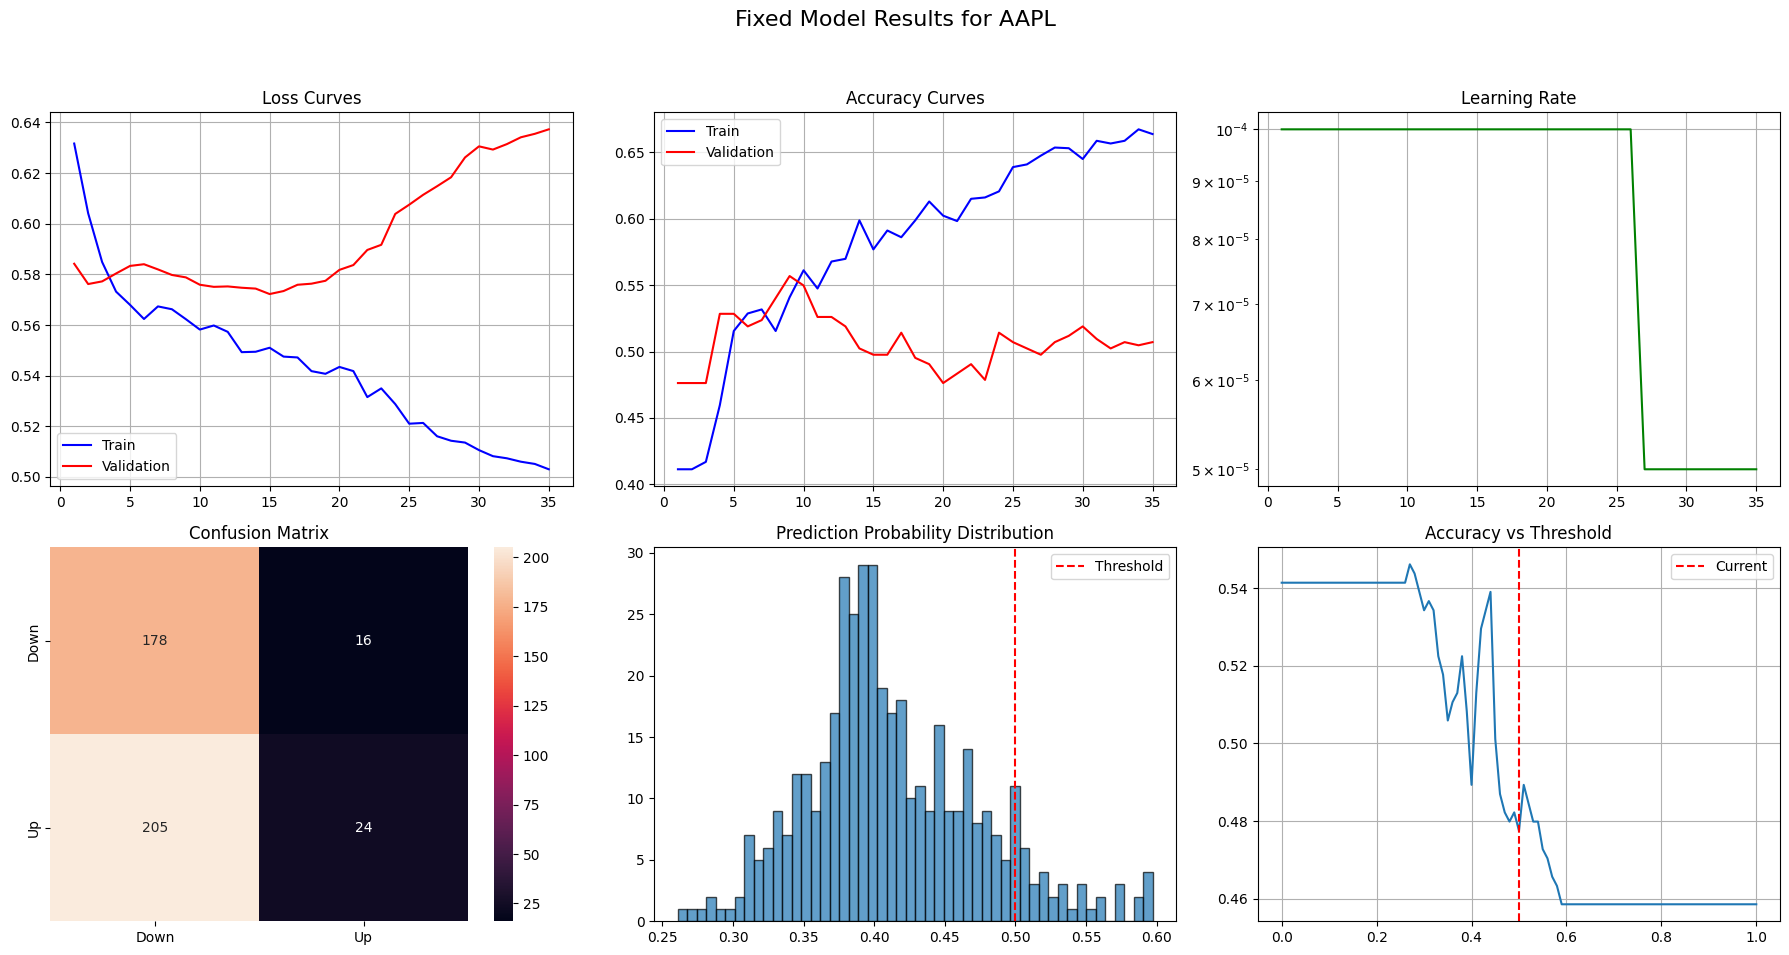

In [8]:
# Cell 8: Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Fixed Model Results for {STOCK_TO_USE}', fontsize=16)

# Training curves
epochs = range(1, len(train_losses) + 1)
axes[0,0].plot(epochs, train_losses, 'b-', label='Train')
axes[0,0].plot(epochs, val_losses, 'r-', label='Validation')
axes[0,0].set_title('Loss Curves')
axes[0,0].legend()
axes[0,0].grid(True)

# Accuracy curves
axes[0,1].plot(epochs, train_accs, 'b-', label='Train')
axes[0,1].plot(epochs, val_accs, 'r-', label='Validation')
axes[0,1].set_title('Accuracy Curves')
axes[0,1].legend()
axes[0,1].grid(True)

# Learning rate
axes[0,2].plot(epochs, learning_rates, 'g-')
axes[0,2].set_title('Learning Rate')
axes[0,2].set_yscale('log')
axes[0,2].grid(True)

# Confusion matrix
cm = confusion_matrix(all_targets, all_predictions)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[1,0], 
           xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
axes[1,0].set_title('Confusion Matrix')

# Prediction distribution
axes[1,1].hist(all_probs, bins=50, alpha=0.7, edgecolor='black')
axes[1,1].axvline(x=0.5, color='r', linestyle='--', label='Threshold')
axes[1,1].set_title('Prediction Probability Distribution')
axes[1,1].legend()

# Accuracy vs threshold
thresholds = np.linspace(0, 1, 101)
threshold_accs = [accuracy_score(all_targets, (np.array(all_probs) > thresh).astype(int)) for thresh in thresholds]
axes[1,2].plot(thresholds, threshold_accs)
axes[1,2].axvline(x=0.5, color='r', linestyle='--', label='Current')
axes[1,2].set_title('Accuracy vs Threshold')
axes[1,2].legend()
axes[1,2].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [9]:
# Check if your target is predictable at all
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train.reshape(len(X_train), -1), y_train)
print(f"RF accuracy: {rf.score(X_test.reshape(len(X_test), -1), y_test):.3f}")

RF accuracy: 0.518
